In [1]:
!pip install chess pandas

In [2]:
import pandas as pd
import chess.pgn
import io
from google.colab import drive
import os

# 1. Hubungkan ke Google Drive
drive.mount('/content/drive')

csv_file_path = "/content/drive/MyDrive/Edlink/chees_datasets_magnus/magnus_carlsen_all_online_games_cleaned.csv"
df = None

try:
    # 2. Load dataset CSV dari Google Drive
    df = pd.read_csv(csv_file_path)
    print("Dataset loaded from Google Drive.")
except FileNotFoundError:
    print(f"File not found in Google Drive: {csv_file_path}")
    print("Attempting to download from Kaggle...")
    try:
        import kagglehub

        # Download latest version of the dataset
        kaggle_path = kagglehub.dataset_download("dhrubangtalukdar/magnus-carlsen-chess-com-games")

        # Construct the full path to the CSV file within the downloaded dataset
        # Assuming the CSV file is directly within the downloaded folder
        csv_file_name = "magnus_carlsen_all_online_games_cleaned.csv"
        kaggle_csv_file_path = os.path.join(kaggle_path, csv_file_name)

        df = pd.read_csv(kaggle_csv_file_path)
        print(f"Dataset loaded from Kaggle at: {kaggle_csv_file_path}")
    except Exception as e:
        print(f"Failed to load dataset from Kaggle: {e}")

# 3. Tampilkan 5 baris pertama untuk inspeksi data
if df is not None:
    display(df[['year', 'player_color', 'opponent_name', 'result']].head())
else:
    print("DataFrame could not be loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File not found in Google Drive: /content/drive/MyDrive/Edlink/chees_datasets_magnus/magnus_carlsen_all_online_games_cleaned.csv
Attempting to download from Kaggle...
Using Colab cache for faster access to the 'magnus-carlsen-chess-com-games' dataset.
Dataset loaded from Kaggle at: /kaggle/input/magnus-carlsen-chess-com-games/magnus_carlsen_all_online_games_cleaned.csv


,year,player_color,opponent_name,result
0,2014,white,RainnWilson,Win
1,2014,white,solskytz,Win
2,2014,white,Tildenbeatsu,Win
3,2014,white,mtmnfy,Win
4,2014,white,stepanosinovsky,Loss


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Blok 2: Load dan Cek Dataset

Gunakan blok ini untuk menghubungkan Google Drive dan memuat file CSV ke dalam DataFrame.

Notes: (rook, knight, bishop, queen, king), dan huruf besar mewakili bidak Putih.

In [4]:
# 1. Ambil data langkah (moves) dari pertandingan pertama (index 0)
langkah_game_1 = df['moves'].iloc[0]

# 2. Konversi teks ke stream agar bisa dibaca python-chess
pgn_io = io.StringIO(langkah_game_1)
game = chess.pgn.read_game(pgn_io)

# 3. Inisialisasi papan catur virtual
board = game.board()

# 4. Simulasikan 5 langkah pertama
for i, move in enumerate(game.mainline_moves()):
    board.push(move)
    if i == 4: # Berhenti di langkah ke-5 (index 4)
        break

# 5. Tampilkan visualisasi papan
print("Visualisasi Papan (Langkah ke-5):")
print(board)

Visualisasi Papan (Langkah ke-5):
r n b q k b n r
p p p . p p . p
. . . p . . p .
. . . . . . . .
. . . P P . . .
. . . . . N . .
P P P . . P P P
R N B Q K B . R


Blok 3: Visualisasi Papan Catur

Blok ini khusus memproses teks langkah catur menjadi papan visual.

In [5]:
import io
import chess.pgn
import chess.svg
from IPython.display import display, HTML

# 1. Ambil data langkah dari pertandingan pertama
langkah_game_1 = df['moves'].iloc[0]

# 2. Konversi teks ke stream
pgn_io = io.StringIO(langkah_game_1)
game = chess.pgn.read_game(pgn_io)

# 3. Inisialisasi papan catur virtual
board = game.board()

# Tampilkan posisi awal sebelum ada pergerakan
print("--- Posisi Awal ---")
display(HTML(chess.svg.board(board=board, size=300)))

# 4. Simulasikan dan tampilkan 5 langkah pertama satu per satu
for i, move in enumerate(game.mainline_moves()):
    board.push(move) # Jalankan langkah

    # Cetak keterangan langkah dan tampilkan papannya
    print(f"\n--- Langkah ke-{i+1} (Index {i}): {move} ---")
    grafis_papan = chess.svg.board(board=board, size=300)
    display(HTML(grafis_papan))

    if i == 4: # Hentikan setelah 5 langkah (index 0, 1, 2, 3, 4)
        break

--- Posisi Awal ---



--- Langkah ke-1 (Index 0): e2e4 ---



--- Langkah ke-2 (Index 1): g7g6 ---



--- Langkah ke-3 (Index 2): g1f3 ---



--- Langkah ke-4 (Index 3): d7d6 ---



--- Langkah ke-5 (Index 4): d2d4 ---


FUTURE ENGINEERING

In [6]:
# Blok 4 (Revisi: Visualisasi Matriks 5 Langkah Pertama)
import numpy as np
import io
import chess.pgn

def board_to_matrix(board):
    # Buat matriks kosong berukuran 8x8x12
    matrix = np.zeros((8, 8, 12), dtype=np.int8)

    # Kamus pemetaan bidak ke index lapisan
    piece_to_index = {
        'P': 0, 'N': 1, 'B': 2, 'R': 3, 'Q': 4, 'K': 5,   # Bidak Putih
        'p': 6, 'n': 7, 'b': 8, 'r': 9, 'q': 10, 'k': 11  # Bidak Hitam
    }

    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece:
            row = 7 - chess.square_rank(square)
            col = chess.square_file(square)
            channel = piece_to_index[piece.symbol()]
            matrix[row, col, channel] = 1

    return matrix

# --- Tes Visualisasi Matriks dari Index 0 sampai 4 ---
# Ambil data langkah dari pertandingan pertama di dataset
langkah_game_1 = df['moves'].iloc[0]
pgn_io = io.StringIO(langkah_game_1)
game = chess.pgn.read_game(pgn_io)
board = game.board()

print("Bentuk (Shape) Matriks:", board_to_matrix(board).shape)
print("Menampilkan Lapisan 0 (Khusus Pion Putih 'P') selama 5 langkah pertama:\n")

# Tampilkan posisi awal
print("--- Posisi Awal ---")
print(board_to_matrix(board)[:, :, 0])

# Simulasikan dan tampilkan 5 langkah pertama
for i, move in enumerate(game.mainline_moves()):
    board.push(move) # Eksekusi langkah di papan virtual
    matriks_hasil = board_to_matrix(board) # Konversi ke matriks

    print(f"\n--- Langkah ke-{i+1} (Index {i}): {move} ---")
    print(matriks_hasil[:, :, 0]) # Cetak hanya lapisan Pion Putih

    if i == 4: # Berhenti di langkah ke-5
        break

Bentuk (Shape) Matriks: (8, 8, 12)
Menampilkan Lapisan 0 (Khusus Pion Putih 'P') selama 5 langkah pertama:

--- Posisi Awal ---
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0]]

--- Langkah ke-1 (Index 0): e2e4 ---
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0]
 [1 1 1 1 0 1 1 1]
 [0 0 0 0 0 0 0 0]]

--- Langkah ke-2 (Index 1): g7g6 ---
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0]
 [1 1 1 1 0 1 1 1]
 [0 0 0 0 0 0 0 0]]

--- Langkah ke-3 (Index 2): g1f3 ---
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0]
 [1 1 1 1 0 1 1 1]
 [0 0 0 0 0 0 0 0]]

--- Langkah ke-4 (Index 3): d7d6 ---
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0

In [7]:
# Blok 5: Ekstraksi Dataset Bersih
import io
import chess.pgn
import numpy as np
import logging

# Membisukan peringatan (error merah) dari library catur
logging.getLogger("chess.pgn").setLevel(logging.CRITICAL)

X = []
y = []
jumlah_game = len(df) # jumlah ai menghapal langkah
game_berhasil = 0

print(f"Memulai ekstraksi data dari {jumlah_game} pertandingan pertama...")

for index, row in df.head(jumlah_game).iterrows():
    try:
        langkah_game = row['moves']
        pgn_io = io.StringIO(langkah_game)
        game = chess.pgn.read_game(pgn_io)
        board = game.board()

        for move in game.mainline_moves():
            X.append(board_to_matrix(board))

            # Rumus label: (kotak_asal * 64) + kotak_tujuan
            label_langkah = (move.from_square * 64) + move.to_square
            y.append(label_langkah)

            board.push(move)

        game_berhasil += 1
    except Exception:
        continue # Lewati jika ada format langkah catur yang aneh

X = np.array(X)
y = np.array(y)

print(f"Ekstraksi Selesai! Berhasil memproses {game_berhasil} dari {jumlah_game} pertandingan.")
print("Bentuk dataset X (Posisi Papan) :", X.shape)
print("Bentuk dataset y (Langkah)      :", y.shape)

Memulai ekstraksi data dari 17125 pertandingan pertama...
Ekstraksi Selesai! Berhasil memproses 17119 dari 17125 pertandingan.
Bentuk dataset X (Posisi Papan) : (1463436, 8, 8, 12)
Bentuk dataset y (Langkah)      : (1463436,)


Membangun architecture AI

In [8]:
# Blok 6: Arsitektur Deep Learning untuk Bot Catur
import tensorflow as tf
from tensorflow.keras import layers, models

def bangun_model_catur():
    model = models.Sequential()

    # Layer Input: Menerima matriks papan catur (8x8x12)
    model.add(layers.Input(shape=(8, 8, 12)))

    # Meratakan matriks 3D menjadi array 1D
    model.add(layers.Flatten())

    # Hidden Layer (Otak AI)
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(256, activation='relu'))

    # Layer Output: 4096 kemungkinan gerakan
    # Softmax akan memilih langkah dengan persentase kecocokan tertinggi
    model.add(layers.Dense(4096, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# Inisialisasi model
ai_catur = bangun_model_catur()

# Menampilkan ringkasan arsitektur model
print("Arsitektur AI Catur Berhasil Dibuat!")
ai_catur.summary()

Arsitektur AI Catur Berhasil Dibuat!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4096)           │     1,052,672 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,577,728 (6.02 MB)

 Trainable params: 1,577,728 (6.02 MB)

 Non-trainable params: 0 (0.00 B)

TRAINNING AI

In [9]:
# Blok 7: Proses Training Model dengan Checkpoint
from tensorflow.keras.callbacks import ModelCheckpoint

# Menentukan nama file checkpoint
# Nanti file ini akan otomatis tersimpan di area folder Colab kamu
nama_file_model = "model_catur_magnus.keras"

# Membuat aturan checkpoint:
# Hanya menyimpan model jika akurasinya (accuracy) meningkat
checkpoint = ModelCheckpoint(
    filepath=nama_file_model,
    save_best_only=True,
    monitor='accuracy',
    mode='max',
    verbose=1
)

print("Mulai proses belajar (Training)...")

# Memasukkan data X dan y ke dalam model
# epochs=15 berarti AI akan membaca seluruh 9.221 data sebanyak 15 kali putaran
history = ai_catur.fit(
    X, y,
    epochs=50,
    batch_size=512,
    callbacks=[checkpoint]
)

print(f"\nTraining selesai! Model terbaik telah disimpan dengan nama: {nama_file_model}")

Mulai proses belajar (Training)...
Epoch 1/50
2859/2859 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0812 - loss: 5.4932
Epoch 1: accuracy improved from None to 0.11567, saving model to model_catur_magnus.keras

Epoch 1: finished saving model to model_catur_magnus.keras
2859/2859 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.1157 - loss: 4.7782
Epoch 2/50
2858/2859 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1681 - loss: 3.8616
Epoch 2: accuracy improved from 0.11567 to 0.17116, saving model to model_catur_magnus.keras

Epoch 2: finished saving model to model_catur_magnus.keras
2859/2859 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.1712 - loss: 3.8221
Epoch 3/50
2848/2859 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1919 - loss: 3.5933
Epoch 3: accuracy improved from 0.17116 to 0.19124, saving model to model_catur_magnus.keras

Epoch 3: finished saving model to model_catur_magnus.keras
2859/2859 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.1912 - loss: 3.5988
Epoch 4/50


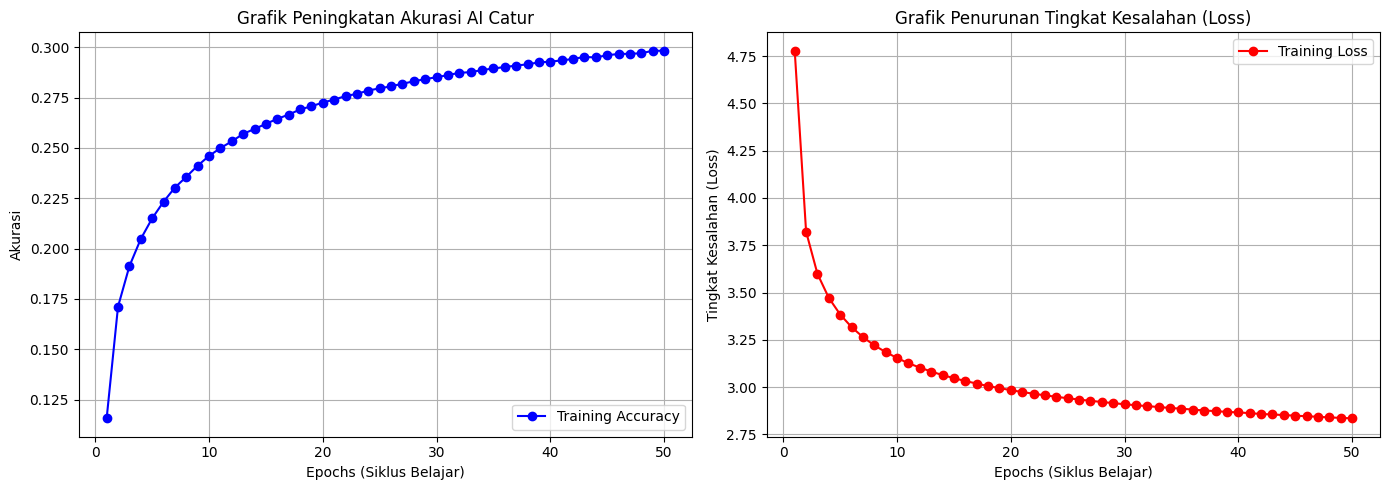

In [10]:
# Blok 8: Evaluasi dan Visualisasi Hasil Training (Poin D)
import matplotlib.pyplot as plt

# Mengekstrak data metrik dari history belajar
akurasi = history.history['accuracy']
loss = history.history['loss']
epochs_range = range(1, len(akurasi) + 1)

# Membuat kerangka gambar (1 baris, 2 kolom)
plt.figure(figsize=(14, 5))

# Grafik 1: Akurasi (Semakin naik semakin pintar)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, akurasi, label='Training Accuracy', color='blue', marker='o')
plt.title('Grafik Peningkatan Akurasi AI Catur')
plt.xlabel('Epochs (Siklus Belajar)')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True)

# Grafik 2: Loss (Semakin turun semakin sedikit error-nya)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='red', marker='o')
plt.title('Grafik Penurunan Tingkat Kesalahan (Loss)')
plt.xlabel('Epochs (Siklus Belajar)')
plt.ylabel('Tingkat Kesalahan (Loss)')
plt.legend(loc='upper right')
plt.grid(True)

# Tampilkan grafiknya
plt.tight_layout()
plt.show()

In [11]:
# Blok 9: Uji Coba Prediksi AI (Inference) dengan Filter Legalitas
import numpy as np
import chess
from IPython.display import display, HTML

def prediksi_langkah_legal(board, model):
    # 1. Konversi papan ke matriks
    matriks_input = board_to_matrix(board)

    # 2. Tambah dimensi karena Keras butuh input (batch, baris, kolom, channel)
    # Ubah bentuk dari (8, 8, 12) menjadi (1, 8, 8, 12)
    matriks_input = np.expand_dims(matriks_input, axis=0)

    # 3. Prediksi 4096 probabilitas (tanpa mencetak loading bar)
    prediksi = model.predict(matriks_input, verbose=0)[0]

    # 4. Urutkan probabilitas dari yang paling tinggi ke rendah
    # argsort() mengurutkan dari kecil ke besar, jadi kita balik pakai [::-1]
    indeks_terbaik = np.argsort(prediksi)[::-1]

    # 5. Cari langkah PERTAMA yang SAH menurut aturan catur
    for indeks in indeks_terbaik:
        from_sq = indeks // 64
        to_sq = indeks % 64
        langkah_kandidat = chess.Move(from_sq, to_sq)

        # Jika langkah tersebut legal di posisi papan saat ini, langsung pilih!
        if langkah_kandidat in board.legal_moves:
            return langkah_kandidat

    return None

# --- MARI KITA UJI AI KAMU BERMAIN ---
papan_tes = chess.Board() # Posisi awal catur
print("--- Papan Sebelum Langkah AI ---")
display(HTML(chess.svg.board(board=papan_tes, size=300)))

# Minta AI berpikir
print("\nAI sedang berpikir...")
langkah_ai = prediksi_langkah_legal(papan_tes, ai_catur)

print(f"Langkah pilihan AI (Gaya Magnus Carlsen): {langkah_ai}")

# Jalankan langkah tersebut di papan
papan_tes.push(langkah_ai)
print("\n--- Papan Setelah Langkah AI ---")
display(HTML(chess.svg.board(board=papan_tes, size=300)))

--- Papan Sebelum Langkah AI ---



AI sedang berpikir...
Langkah pilihan AI (Gaya Magnus Carlsen): e2e4

--- Papan Setelah Langkah AI ---


In [12]:
# Blok 11 (Revisi V3: GUI Anti-Ngebug & Fitur Reset)
import chess
from google.colab import output
import IPython

# Inisialisasi papan
papan_gui = chess.Board()

def reset_papan():
    global papan_gui
    papan_gui = chess.Board()
    return IPython.display.JSON({'fen': papan_gui.fen(), 'status': 'Mulai'})

def proses_langkah_web(source, target):
    global papan_gui
    move_str = source + target

    # Deteksi promosi pion
    if chess.Move.from_uci(move_str + 'q') in papan_gui.legal_moves:
        move_str += 'q'

    try:
        move = chess.Move.from_uci(move_str)
        if move in papan_gui.legal_moves:
            papan_gui.push(move)

            if papan_gui.is_game_over():
                return IPython.display.JSON({'fen': papan_gui.fen(), 'status': 'Game Over'})

            # Giliran AI membalas
            langkah_ai = prediksi_langkah_legal(papan_gui, ai_catur)
            if langkah_ai:
                papan_gui.push(langkah_ai)

            return IPython.display.JSON({'fen': papan_gui.fen(), 'status': 'Berjalan'})
        else:
            return IPython.display.JSON({'fen': papan_gui.fen(), 'status': 'Illegal', 'move': move_str})
    except:
        return IPython.display.JSON({'fen': papan_gui.fen(), 'status': 'Illegal', 'move': move_str})

# Mendaftarkan fungsi Python ke Web JavaScript
output.register_callback('proses_langkah_web', proses_langkah_web)
output.register_callback('reset_papan', reset_papan)

# Merender Tampilan Web Interaktif
html_code = """
<link rel="stylesheet" href="https://unpkg.com/@chrisoakman/chessboardjs@1.0.0/dist/chessboard-1.0.0.min.css">
<script src="https://code.jquery.com/jquery-3.5.1.min.js"></script>
<script src="https://unpkg.com/@chrisoakman/chessboardjs@1.0.0/dist/chessboard-1.0.0.min.js"></script>

<div style="max-width: 450px; margin: 10px auto; font-family: Arial, sans-serif; text-align: center;">
    <h3 style="color: #333;">♟️ AI Catur Magnus Carlsen ♟️</h3>
    <div id="papanCatur" style="width: 100%;"></div>
    <button onclick="resetGame()" style="margin-top: 15px; padding: 10px 20px; font-weight: bold; cursor: pointer; background-color: #ff4c4c; color: white; border: none; border-radius: 5px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">🔄 Mulai Ulang Game</button>
    <p id="status_game" style="font-weight: bold; margin-top: 15px; color: #0066cc;">Status: Giliranmu (Tarik bidak Putih)</p>
</div>

<script>
var board = null;

function onDragStart (source, piece, position, orientation) {
  // FITUR BARU: Mencegah kamu narik bidak hitam secara tidak sengaja
  if (piece.search(/^b/) !== -1) return false;
}

function onDrop (source, target) {
  if (source === target) return 'snapback';

  document.getElementById('status_game').innerText = "Status: AI sedang berpikir keras...";

  (async function() {
      const result = await google.colab.kernel.invokeFunction(
          'proses_langkah_web',
          [source, target],
          {}
      );

      const data = result.data['application/json'];
      board.position(data.fen);

      if (data.status === 'Illegal') {
          document.getElementById('status_game').innerText = "❌ Langkah (" + data.move + ") dilarang aturan! Coba langkah lain.";
      } else if (data.status === 'Game Over') {
          document.getElementById('status_game').innerText = "🏁 Permainan Selesai!";
      } else {
          document.getElementById('status_game').innerText = "✅ Giliranmu (Putih). Tarik bidakmu.";
      }
  })();
}

async function resetGame() {
    const result = await google.colab.kernel.invokeFunction('reset_papan', [], {});
    const data = result.data['application/json'];
    board.position(data.fen);
    document.getElementById('status_game').innerText = "Status: Game direset! Giliranmu (Putih).";
}

var config = {
  draggable: true,
  position: 'start',
  onDragStart: onDragStart,
  onDrop: onDrop,
  pieceTheme: 'https://chessboardjs.com/img/chesspieces/wikipedia/{piece}.png'
};
board = Chessboard('papanCatur', config);
</script>
"""

display(IPython.display.HTML(html_code))

In [13]:
from google.colab import drive
import shutil

# 1. Mount Google Drive-mu
drive.mount('/content/drive')

# 2. Salin file model ke folder utama Drive-mu
# Pastikan nama filenya sama persis dengan yang ada di folder Colab
shutil.copy('model_catur_magnus.keras', '/content/drive/MyDrive/model_catur_magnus.keras')

print("Selesai! File sudah tersalin ke Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Selesai! File sudah tersalin ke Google Drive.
